In [1]:
#installs
install.packages('caret')
install.packages('glmnet')
install.packages('earth')
install.packages('mgcv')
install.packages('randomForest')
install.packages('xgboost')
install.packages('pdp')
install.packages('interpret')


The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages


Warning message:
"package 'interpret' is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"


In [4]:
## libraries
library(tidyverse)
library(caret)
library(glmnet)
library(earth)
library(mgcv)
library(randomForest)
library(xgboost)
library(pdp)
library(interpret)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v ggplot2   3.5.1     v tibble    3.2.1
v lubridate 1.9.3     v tidyr     1.3.1
v purrr     1.0.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift


Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-8

Loading required package: Formula

Loading required package: plotmo

Loading required package: plotrix

Loading required package: nlme


Attaching package: 'nlme'


The followin

#### Section 1

You are going to evaluate a telecommunications churn dataset for this question. You are going to be solving a classification model to model churn using a variety of factors. 

Run the following code to obtain the churn dataset:

training <- read.csv("https://raw.githubusercontent.com/IAA-Faculty/statistical_foundations/master/tele_churn3.csv")

Use the above dataset created from the code to answer the following questions.

In [5]:
df <- read.csv("https://raw.githubusercontent.com/IAA-Faculty/statistical_foundations/master/tele_churn3.csv")
head(df)

,account.length,international.plan,voice.mail.plan,total.day.charge,total.intl.calls,customer.service.calls,churn
,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<lgl>
1,105,no,no,25.11,3,2,FALSE
2,50,no,yes,51.46,14,3,FALSE
3,118,no,no,23.14,4,1,FALSE
4,97,no,no,28.85,6,3,FALSE
5,51,no,no,38.62,2,0,FALSE
6,35,no,no,21.11,8,2,FALSE


In [6]:
# make the target variable a factor
df$churn <- as.factor(df$churn)

In [8]:
# binary target variable, so we need to specify the glm argument as binomial
mars1 <- earth(churn ~ ., data = df, glm = list(family=binomial))

summary(mars1)

Call: earth(formula=churn~., data=df, glm=list(family=binomial))

GLM coefficients
                                  TRUE
(Intercept)                  6.5622150
international.planyes        2.0733197
voice.mail.planyes          -1.1168687
h(account.length-67)         0.0072828
h(total.day.charge-17.63)   -0.5651256
h(total.day.charge-30.7)     0.3320014
h(39.17-total.day.charge)   -0.3874845
h(total.day.charge-39.17)    0.5507772
h(total.intl.calls-2)       -0.3197912
h(total.intl.calls-8)        0.6815806
h(customer.service.calls-3)  2.4700268
h(customer.service.calls-4) -2.0510433

GLM (family binomial, link logit):
 nulldev   df       dev   df   devratio     AIC iters converged
 1056.12 1824   691.843 1813      0.345   715.8     7         1

Earth selected 12 of 15 terms, and 6 of 6 predictors
Termination condition: Reached nk 21
Importance: total.day.charge, customer.service.calls, ...
Number of terms at each degree of interaction: 1 11 (additive model)
Earth GCV 0.05791448    RSS 

In [9]:
evimp(mars1)

                       nsubsets   gcv    rss
total.day.charge             11 100.0  100.0
customer.service.calls       10  69.7   71.6
international.planyes         9  47.4   51.3
voice.mail.planyes            8  28.7   35.3
total.intl.calls              6  19.4   26.7
account.length                1   2.2    8.0

#### Section 2

Similar to the last problem, you are going to evaluate a telecommunications churn dataset for this question. You are going to be solving a classification model to model churn using a variety of factors. 

Run the following code to obtain the churn dataset:

training <- read.csv("https://raw.githubusercontent.com/IAA-Faculty/statistical_foundations/master/tele_churn3.csv")

Use the above dataset created from the code to answer the following questions.

In [10]:
df2 <- read.csv("https://raw.githubusercontent.com/IAA-Faculty/statistical_foundations/master/tele_churn3.csv")
head(df)

,account.length,international.plan,voice.mail.plan,total.day.charge,total.intl.calls,customer.service.calls,churn
,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<fct>
1,105,no,no,25.11,3,2,FALSE
2,50,no,yes,51.46,14,3,FALSE
3,118,no,no,23.14,4,1,FALSE
4,97,no,no,28.85,6,3,FALSE
5,51,no,no,38.62,2,0,FALSE
6,35,no,no,21.11,8,2,FALSE


In [11]:
df2$churn <- as.factor(df2$churn)

In [14]:
gam <- mgcv::gam(churn ~ s(total.intl.calls, k = 3) + account.length + factor(international.plan) + factor(voice.mail.plan) + total.day.charge + customer.service.calls, method = 'REML', data = df2, family=binomial)

summary(gam)


Family: binomial 
Link function: logit 

Formula:
churn ~ s(total.intl.calls, k = 3) + account.length + factor(international.plan) + 
    factor(voice.mail.plan) + total.day.charge + customer.service.calls

Parametric coefficients:
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                   -6.535640   0.497211 -13.145  < 2e-16 ***
account.length                 0.003841   0.002315   1.659   0.0971 .  
factor(international.plan)yes  1.960648   0.234833   8.349  < 2e-16 ***
factor(voice.mail.plan)yes    -0.982893   0.244578  -4.019 5.85e-05 ***
total.day.charge               0.082001   0.010939   7.496 6.58e-14 ***
customer.service.calls         0.513759   0.063777   8.056 7.91e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                      edf Ref.df Chi.sq  p-value    
s(total.intl.calls) 1.929  1.995  22.09 2.96e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*'

In [15]:
gam2 <- mgcv::gam(churn ~ s(total.intl.calls, k = 3), method = 'REML', data = df2, family=binomial)
summary(gam2)


Family: binomial 
Link function: logit 

Formula:
churn ~ s(total.intl.calls, k = 3)

Parametric coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.42904    0.08751  -27.76   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                      edf Ref.df Chi.sq  p-value    
s(total.intl.calls) 1.882  1.986  17.63 0.000339 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.00853   Deviance explained = 1.65%
-REML =    524  Scale est. = 1         n = 1825

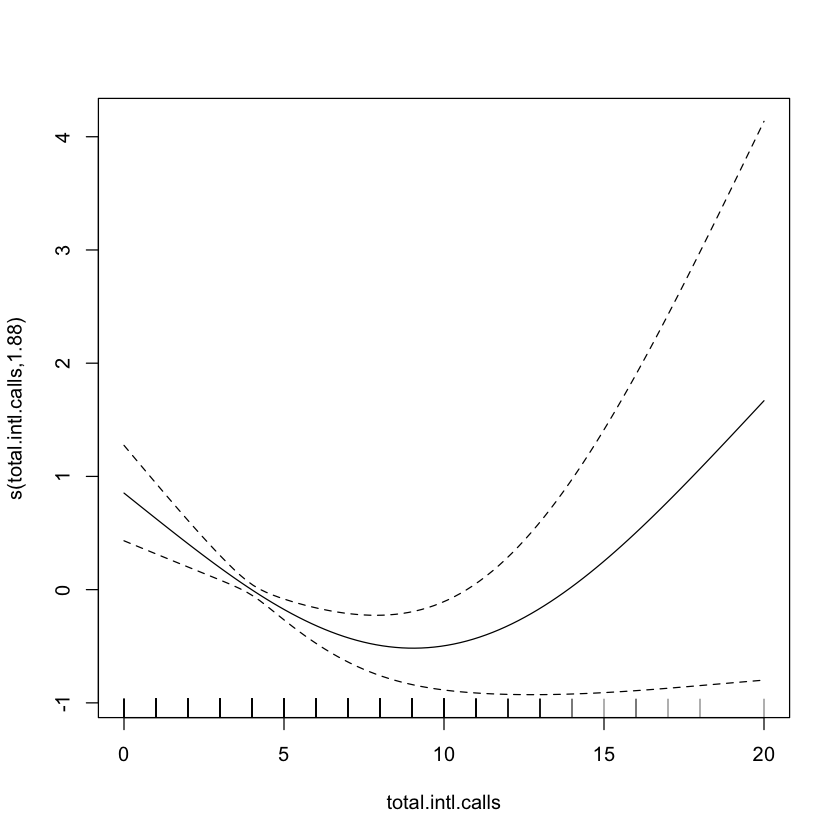

In [16]:
plot(gam2)

#### Section 3

Similar to the previous coding problems, you are going to evaluate a telecommunications churn dataset for this question. You are going to be solving a classification model to model churn using a variety of factors. 

Run the following code to obtain the churn dataset:

training <- read.csv("https://raw.githubusercontent.com/IAA-Faculty/statistical_foundations/master/tele_churn3.csv")

Use the above dataset created from the code to answer the following questions.

In [18]:
df3 <- read.csv("https://raw.githubusercontent.com/IAA-Faculty/statistical_foundations/master/tele_churn3.csv")
head(df3)

,account.length,international.plan,voice.mail.plan,total.day.charge,total.intl.calls,customer.service.calls,churn
,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<lgl>
1,105,no,no,25.11,3,2,FALSE
2,50,no,yes,51.46,14,3,FALSE
3,118,no,no,23.14,4,1,FALSE
4,97,no,no,28.85,6,3,FALSE
5,51,no,no,38.62,2,0,FALSE
6,35,no,no,21.11,8,2,FALSE


In [19]:
df3$churn <- as.factor(df3$churn)

set.seed(8675309)

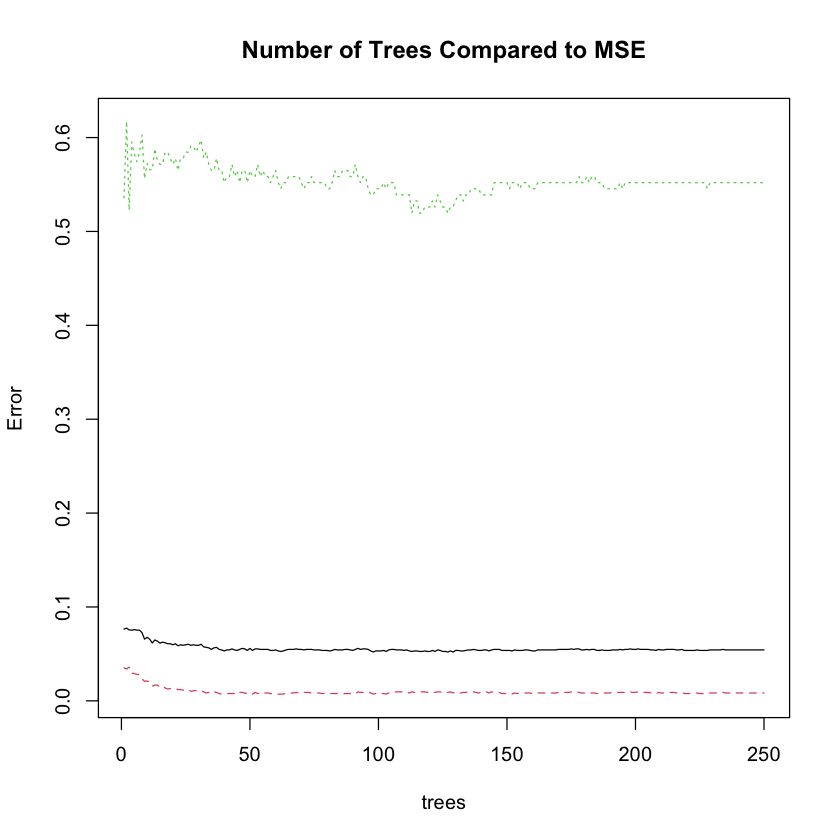

In [20]:
rf.df3 <- randomForest(churn ~ ., data = df3, ntree = 250, importance = TRUE)

plot(rf.df3, main = "Number of Trees Compared to MSE")

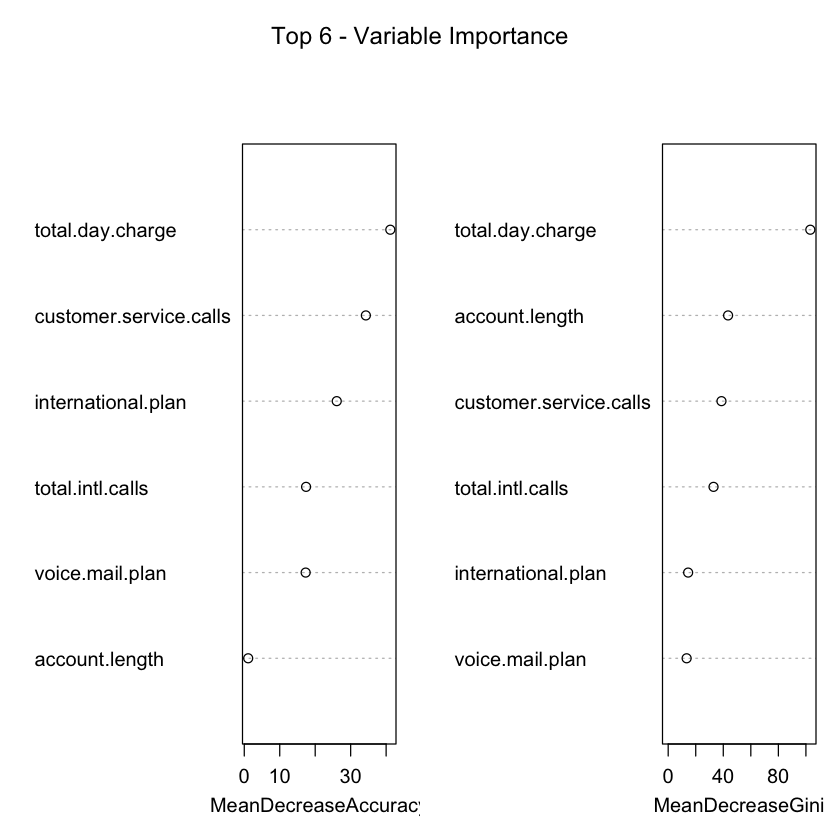

In [25]:
varImpPlot(rf.df3,
           sort = TRUE,
           n.var = 6,
           main = "Top 6 - Variable Importance")

In [24]:
importance(rf.df3)

,FALSE,TRUE,MeanDecreaseAccuracy,MeanDecreaseGini
account.length,0.1111526,2.23546,1.104994,43.48576
international.plan,20.2130409,22.33378,26.074177,14.48321
voice.mail.plan,11.0414972,16.32951,17.311060,13.39368
total.day.charge,29.2851105,39.36131,41.181215,103.19555
total.intl.calls,12.4179719,14.23590,17.425702,32.92430
customer.service.calls,21.2354340,35.15008,34.286490,38.68008


### ML FINAL

In [60]:
#installs
install.packages('caret')
install.packages('glmnet')
install.packages('earth')
install.packages('mgcv')
install.packages('randomForest')
install.packages('xgboost')
install.packages('pdp')
install.packages('interpret')


The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages


Warning message:
"package 'interpret' is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"


In [2]:
# installs Pt. 2
install.packages("nnet")
install.packages("NeuralNetTools")
install.packages("caret")
install.packages("ggplot2")
install.packages("reshape2")
install.packages("e1071")
install.packages("klaR")
install.packages("randomForest")
install.packages("iml")
install.packages("patchwork")


The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages


also installing the dependencies 'classInt', 'combinat', 'questionr'





The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages


also installing the dependency 'Metrics'





The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages

The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages


In [ ]:
## load
library(tidyverse)
library(caret)
library(glmnet)
library(earth)
library(mgcv)
library(randomForest)
library(xgboost)
library(pdp)
library(interpret)

In [3]:
# load Pt.2
library(nnet)
library(NeuralNetTools)
library(caret)
library(ggplot2)
library(reshape2)
library(e1071)
library(klaR)
library(randomForest)
library(iml)
library(patchwork)

Loading required package: ggplot2

Loading required package: lattice

Loading required package: MASS

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: 'randomForest'


The following object is masked from 'package:ggplot2':

    margin



Attaching package: 'patchwork'


The following object is masked from 'package:MASS':

    area




### Final | Section 1
- You are going to evaluate a telecommunications churn dataset for this question. You are going to be solving a classification model to model churn using a variety of factors. 

- Run the following code to obtain the churn dataset:

training <- read.csv("https://raw.githubusercontent.com/IAA-Faculty/statistical_foundations/master/tele_churn3.csv")

- Use the above dataset created from the code to answer the following questions.

In [4]:
training <- read.csv("https://raw.githubusercontent.com/IAA-Faculty/statistical_foundations/master/tele_churn3.csv")

In [5]:
head(training)

,account.length,international.plan,voice.mail.plan,total.day.charge,total.intl.calls,customer.service.calls,churn
,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<lgl>
1,105,no,no,25.11,3,2,FALSE
2,50,no,yes,51.46,14,3,FALSE
3,118,no,no,23.14,4,1,FALSE
4,97,no,no,28.85,6,3,FALSE
5,51,no,no,38.62,2,0,FALSE
6,35,no,no,21.11,8,2,FALSE


In [7]:
sum(training$churn == FALSE)

[1] 1671

In [8]:
sum(training$churn == TRUE)

[1] 154

In [12]:
library(earth)

training$churn <- as.factor(training$churn)

mars1 <- earth(churn ~ total.day.charge, data = training, glm=list(family=binomial))

summary(mars1)

Call: earth(formula=churn~total.day.charge, data=training,
            glm=list(family=binomial))

GLM coefficients
                                TRUE
(Intercept)                6.7281428
h(total.day.charge-17.6)  -0.5308798
h(total.day.charge-32.37)  0.3568993
h(39.22-total.day.charge) -0.3938682
h(total.day.charge-39.22)  0.4031724
h(total.day.charge-45.97)  0.0317329

GLM (family binomial, link logit):
 nulldev   df       dev   df   devratio     AIC iters converged
 1056.12 1824   892.871 1819      0.155   904.9     7         1

Earth selected 6 of 6 terms, and 1 of 1 predictors
Termination condition: RSq changed by less than 0.001 at 6 terms
Importance: total.day.charge
Number of terms at each degree of interaction: 1 5 (additive model)
Earth GCV 0.06715315    RSS 121.0816    GRSq 0.1318018    RSq 0.1412955

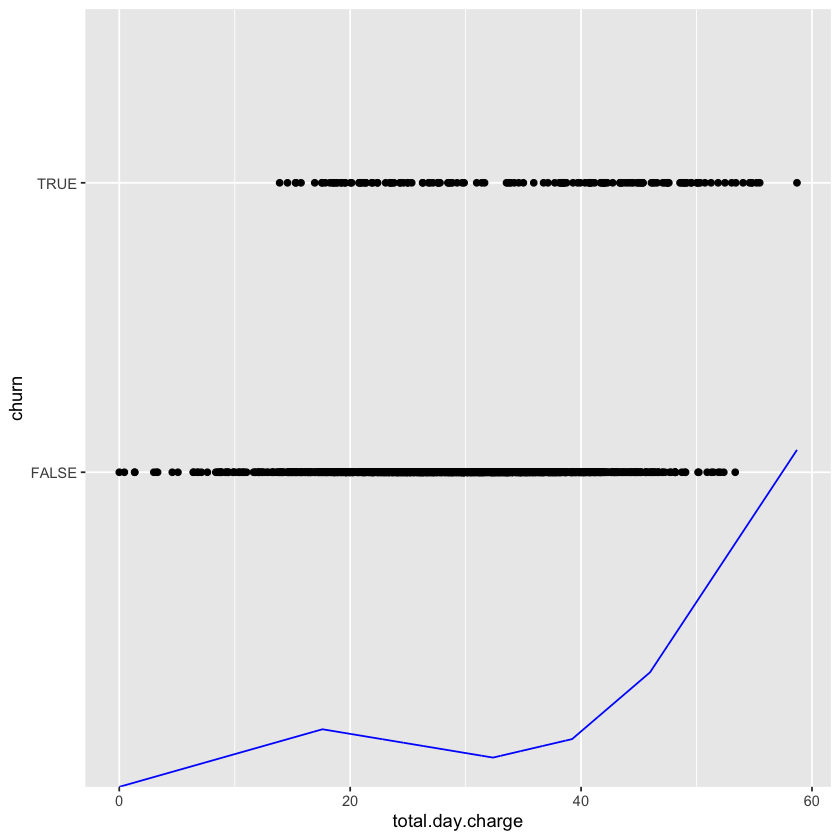

In [13]:
ggplot(training, aes(x = total.day.charge, y = churn)) +
  geom_point() +
  geom_line(data = training, aes(x = total.day.charge, y = mars1$fitted.values), color = "blue")

### Final | Section 2

- Build a GAM in R (using the mgcv::gam function) using only the training data to predict the target variable churn using all other variables as predictors. Splines need to be added to the continuous variables (account.length, total.day.charge, total.intl.calls, customer.service.calls). For the customer.service.calls variable use a k option with a max of 5 for this variable to run.

- DO NOT use any options for variable selection. Make sure to use the "method = 'REML'" option for best estimates.

- Since you have a classification problem you will need to use the "family = " option.

- Use the above information to answer the following questions.

In [14]:
head(training)

,account.length,international.plan,voice.mail.plan,total.day.charge,total.intl.calls,customer.service.calls,churn
,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<fct>
1,105,no,no,25.11,3,2,FALSE
2,50,no,yes,51.46,14,3,FALSE
3,118,no,no,23.14,4,1,FALSE
4,97,no,no,28.85,6,3,FALSE
5,51,no,no,38.62,2,0,FALSE
6,35,no,no,21.11,8,2,FALSE


In [18]:
library(mgcv)

training$international.plan <- as.factor(training$international.plan)

training$voice.mail.plan <- as.factor(training$voice.mail.plan)

gam1 <- mgcv::gam(churn ~ s(account.length) + s(total.day.charge) + s(total.intl.calls) + s(customer.service.calls, k=5) + international.plan + voice.mail.plan, 
                    data = training, method='REML', family=binomial)

summary(gam1)


Family: binomial 
Link function: logit 

Formula:
churn ~ s(account.length) + s(total.day.charge) + s(total.intl.calls) + 
    s(customer.service.calls, k = 5) + international.plan + voice.mail.plan

Parametric coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)            -3.1433     0.1532 -20.521  < 2e-16 ***
international.planyes   2.0866     0.2568   8.125 4.48e-16 ***
voice.mail.planyes     -1.0952     0.2680  -4.086 4.39e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                            edf Ref.df  Chi.sq  p-value    
s(account.length)         1.668  2.100   4.734 0.111954    
s(total.day.charge)       5.318  6.447 141.012  < 2e-16 ***
s(total.intl.calls)       3.952  4.857  24.458 0.000219 ***
s(customer.service.calls) 3.270  3.676  96.597  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.306   Deviance explained = 3

In [19]:
gam2 <- mgcv::gam(churn ~ s(total.day.charge) + s(total.intl.calls) + s(customer.service.calls, k=5) + international.plan + voice.mail.plan, 
                    data = training, method='REML', family=binomial)

summary(gam2)


Family: binomial 
Link function: logit 

Formula:
churn ~ s(total.day.charge) + s(total.intl.calls) + s(customer.service.calls, 
    k = 5) + international.plan + voice.mail.plan

Parametric coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)            -3.1220     0.1518 -20.572  < 2e-16 ***
international.planyes   2.0739     0.2555   8.117 4.77e-16 ***
voice.mail.planyes     -1.0901     0.2665  -4.091 4.30e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                            edf Ref.df Chi.sq  p-value    
s(total.day.charge)       5.301  6.433 142.28  < 2e-16 ***
s(total.intl.calls)       4.064  4.984  23.62 0.000242 ***
s(customer.service.calls) 3.259  3.669  95.41  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.304   Deviance explained = 33.7%
-REML = 373.02  Scale est. = 1         n = 1825

### Final | Section 3

- Build a 10-fold cross validation on an XGBoost model on only the training dataset with a value of 0.5 for subsample and 50 for number of rounds to optimize the number of rounds. Remember that you have a classification problem so include the following options to help: eval.metric = "auc" , objective = "binary:logistic"

- Run the following code RIGHT BEFORE you build your XGBoost model:

set.seed(3920)

- NOTE: If you don't run the set.seed code right before you run your XGBoost model function it will produce the wrong model so make sure to run that code FIRST!


In [32]:
# build X and Y datasets:
train_x <- model.matrix(churn ~ ., data = training)[, -1]
train_y <- training$churn

In [33]:
head(train_y)

[1] FALSE FALSE FALSE FALSE FALSE FALSE
Levels: FALSE TRUE

In [34]:
str(train_y)
unique(train_y)

 Factor w/ 2 levels "FALSE","TRUE": 1 1 1 1 1 1 1 1 1 1 ...


[1] FALSE TRUE 
Levels: FALSE TRUE

In [35]:
train_y <- as.factor(train_y)
unique(train_y)

[1] FALSE TRUE 
Levels: FALSE TRUE

In [36]:
train_y <- as.integer(train_y) - 1

In [38]:
head(train_y)

[1] 0 0 0 0 0 0

In [39]:
# build the xgboost model:
library(xgboost)

set.seed(39320)

xgbcv.tele <- xgb.cv(data = train_x, label = train_y, subsample = 0.5, nrounds = 50, nfold = 10, eval.metric = "auc", objective="binary:logistic")

[1]	train-auc:0.880886+0.020782	test-auc:0.874723+0.043846 
[2]	train-auc:0.897937+0.016724	test-auc:0.886600+0.044211 
[3]	train-auc:0.904790+0.017530	test-auc:0.888007+0.042128 
[4]	train-auc:0.917501+0.007030	test-auc:0.891939+0.034786 
[5]	train-auc:0.923020+0.008213	test-auc:0.892504+0.034407 
[6]	train-auc:0.932551+0.008080	test-auc:0.890067+0.036474 
[7]	train-auc:0.937119+0.007954	test-auc:0.888974+0.033463 
[8]	train-auc:0.944557+0.007279	test-auc:0.890392+0.037516 
[9]	train-auc:0.948296+0.006898	test-auc:0.893185+0.045145 
[10]	train-auc:0.952550+0.006238	test-auc:0.889176+0.052390 
[11]	train-auc:0.954574+0.005019	test-auc:0.884959+0.049990 
[12]	train-auc:0.956702+0.005158	test-auc:0.891784+0.043467 
[13]	train-auc:0.959372+0.005386	test-auc:0.891538+0.041403 
[14]	train-auc:0.962513+0.005428	test-auc:0.889097+0.039322 
[15]	train-auc:0.964683+0.004820	test-auc:0.887514+0.037187 
[16]	train-auc:0.966866+0.004456	test-auc:0.880857+0.041532 
[17]	train-auc:0.969291+0.004325	

In [44]:
train_y <- factor(train_y, levels = c(0,1))
train_y

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [38] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [75] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [112] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [149] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [186] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [223] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [260] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [297] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [334] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [371] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [408] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [445] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [482] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [519] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [556] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [593] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [630] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [667] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [704] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [741] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [778] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [815] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [852] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [889] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [926] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [963] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1000] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1037] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1074] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1111] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1148] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1185] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1222] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1259] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1296] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1333] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1370] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1407] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1444] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1481] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1518] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1555] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1592] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1629] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1666] 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1703] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1740] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1777] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1814] 1 1 1 1 1 1 1 1 1 1 1 1
Lev

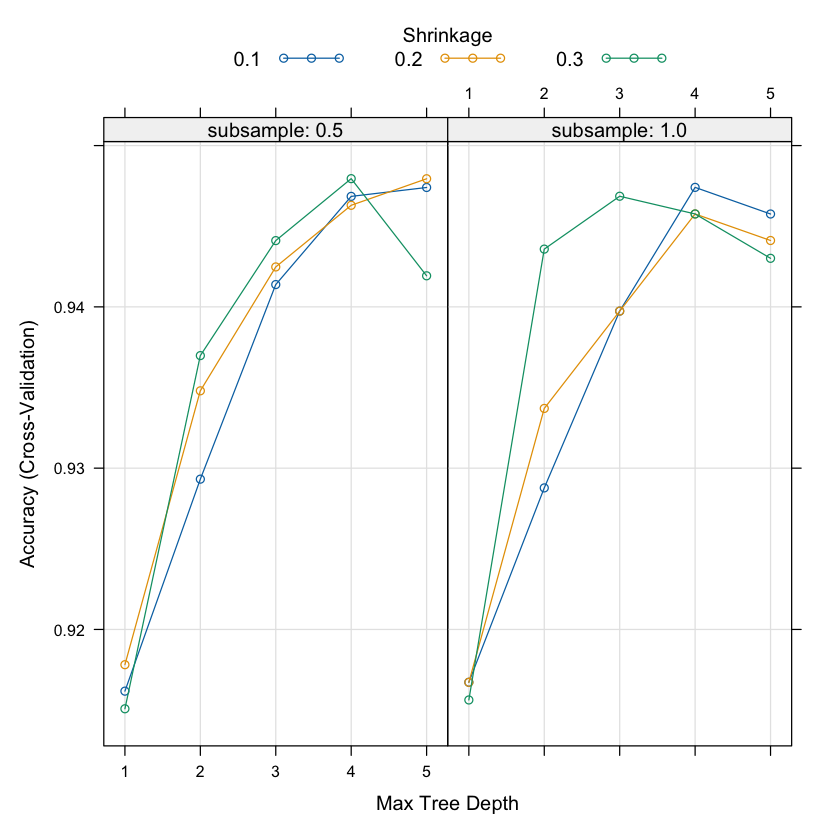

In [45]:
library(caret) 

tune_grid <- expand.grid(
  nrounds = 10,
  eta = c(0.1, 0.2, 0.3),
  max_depth = c(1:5),
  gamma = c(0),
  colsample_bytree = 1,
  min_child_weight = 1,
  subsample = c(0.5, 1)
)

set.seed(3920)

xgb.tele.caret <- train(x = train_x, y = train_y,
      method = "xgbTree",
      tuneGrid = tune_grid,
      trControl = trainControl(method = 'cv', # Using 10-fold cross-validation
                               number = 10))

plot(xgb.tele.caret)

In [50]:
train_y <- as.integer(train_y - 1)
train_y

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [38] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [75] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [112] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [149] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [186] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [223] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [260] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [297] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [334] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [371] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [408] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [445] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [482] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [519] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [556] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [593] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [630] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [667] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [704] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [741] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [778] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [815] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [852] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [889] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [926] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [963] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1000] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1037] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1074] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1111] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1148] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1185] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1222] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1259] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1296] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1333] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1370] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1407] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1444] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1481] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1518] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1555] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1592] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1629] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1666] 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1703] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1740] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1777] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[1814] 1 1 1 1 1 1 1 1 1 1 1 1

In [51]:
set.seed(39320)

final.xgboost.tele <- xgboost(data = train_x, label = train_y, subsample = 1, nrounds = 10, eta=0.3, max_depth=3, eval.metric = "auc", objective="binary:logistic")

[1]	train-auc:0.794232 
[2]	train-auc:0.855701 
[3]	train-auc:0.858204 
[4]	train-auc:0.898717 
[5]	train-auc:0.899539 
[6]	train-auc:0.903268 
[7]	train-auc:0.910290 
[8]	train-auc:0.912000 
[9]	train-auc:0.912998 
[10]	train-auc:0.920038 


In [55]:
xgb.importance(feature_names = colnames(train_x), model = final.xgboost.tele)

Feature,Gain,Cover,Frequency
<chr>,<dbl>,<dbl>,<dbl>
total.day.charge,0.45907974,0.42681539,0.39393939
customer.service.calls,0.20146564,0.27056884,0.15151515
international.planyes,0.11496270,0.20737815,0.13636364
voice.mail.planyes,0.11125514,0.04283481,0.12121212
total.intl.calls,0.09705436,0.03366567,0.09090909
account.length,0.01618241,0.01873714,0.10606061


In [58]:
install.packages("Ckmeans.1d.dp")
library(Ckmeans.1d.dp)


also installing the dependencies 'rbibutils', 'Rdpack'





The downloaded binary packages are in
	/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T//RtmpRiI2Cr/downloaded_packages


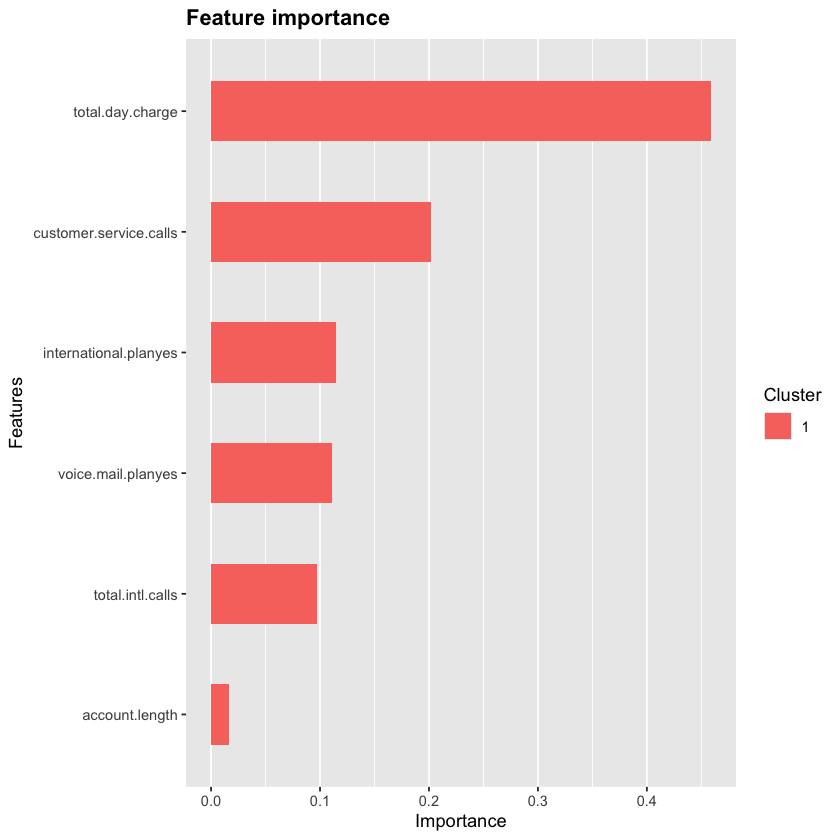

In [59]:
xgb.ggplot.importance(xgb.importance(feature_names = colnames(train_x), model = final.xgboost.tele))